In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Naive Bayes Implementation

Dataset Iris


In [2]:
df = pd.read_csv('https://github.com/lowoncuties/VSB-FEI-Machine-Learning-Exercises/raw/main/datasets/ml_06/iris.csv')
print(df.head())


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


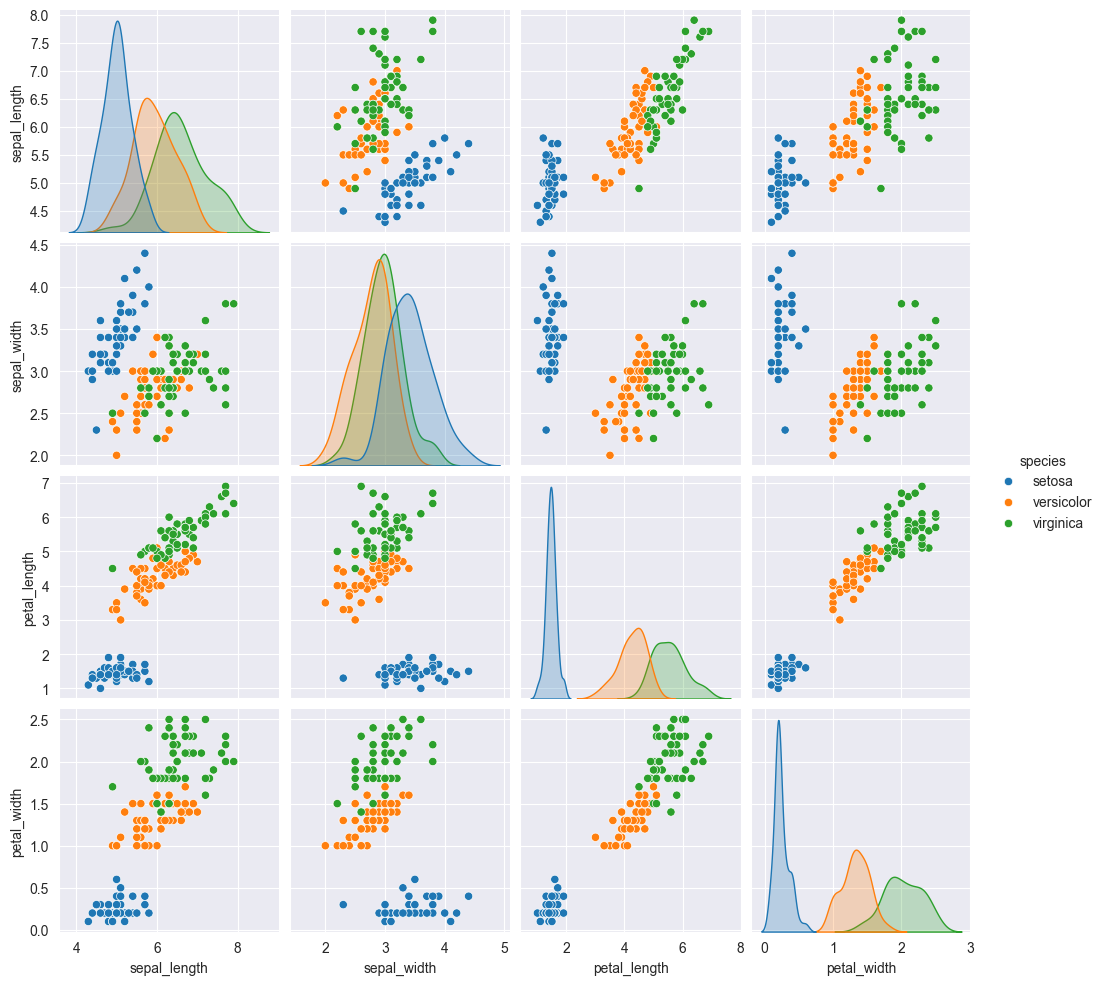

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="species")
plt.show()


## Naive Bayes Klasifikátor

Tento kód implementuje **Naive Bayes klasifikátor** na základe Gaussovho (normálneho) rozdelenia pre každú vlastnosť v dátach. Tu je popis hlavných častí:

### 1. Pomocné funkcie

- **`mean(values)`**: Vypočíta aritmetický priemer zadaných hodnôt.
  $$
  \mu = \frac{1}{N} \sum_{i=1}^{N} x_i
  $$

- **`variance(values, mean)`**: Vypočíta rozptyl hodnôt na základe priemeru.
  $$
  \sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2
  $$

- **`gaussian_probability(x, mean, var)`**: Vypočíta pravdepodobnosť pre hodnotu \(x\) na základe normálneho rozdelenia.
  $$
  P(x | \mu, \sigma^2) = \frac{1}{\sqrt{2\pi \sigma^2}} \exp \left(-\frac{(x - \mu)^2}{2\sigma^2}\right)
  $$

In [4]:
def mean(values):
    return sum(values) / len(values)

In [5]:
def variance(values,mean):
    return sum([(x-mean)**2 for x in values])/ len(values)

In [6]:
def gaussian_probability(x, mean, var): 
    exponent = math.exp(-((x - mean) ** 2) / (2 * var)) 
    return (1 / math.sqrt(2 * math.pi * var)) * exponent


### 2. Trénovanie modelu

Trieda `NaiveBayes` implementuje Naive Bayes klasifikátor:
- **`fit(X, y)`**: Trénuje model na dátach \(X\) a cieľovej premenné \(y\). Pre každú triedu sa vypočíta priemer a rozptyl pre každú vlastnosť.
- **`predict(X)`**: Predikuje triedu pre každú vzorku v testovacej množine.
- **`_predict_single(sample)`**: Vypočíta posteriornú pravdepodobnosť pre každú triedu a vyberie tú s najvyššou hodnotou.


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
class NaiveBayes:
    def fit(self,X,y):
        self.classes = set(y) #jedinecne hodntoy
        self.summaries = {}
        for c in self.classes:
            X_c = [X[i] for i in range(len(X)) if y[i] == c]
            features = list(zip(*X_c))
            summaries = []
            for feature in features:
                mean_val = mean(feature)
                var_val = variance(feature, mean_val)
                summaries.append((mean_val, var_val))
            self.summaries[c] = summaries
    def predict(self,X):
        return [self._predict_single(sample) for sample in X]
    
    def _predict_single(self, sample):
        posterior_probs = {}
        for c in self.classes:
            prior = math.log(sum(1 for label in y_train if label == c) / len(y_train))  # P(c)
            likelihood = 0
            for i in range(len(sample)):
                mean_val, var_val = self.summaries[c][i]
                likelihood += math.log(gaussian_probability(sample[i], mean_val, var_val))  # P(x_i | c)
            posterior_probs[c] = prior + likelihood
        
        return max(self.classes, key=lambda c: posterior_probs[c])
            

### 3. Výpočet posteriornej pravdepodobnosti

Na výpočet posteriornej pravdepodobnosti používame Naive Bayes predpoklad nezávislosti vlastností:
$$
P(c | x) \propto P(c) \cdot \prod_{i=1}^{n} P(x_i | c)
$$
Kde:
- \(P(c)\) je priorná pravdepodobnosť triedy.
- \(P(x_i | c)\) je pravdepodobnosť vlastnosti \(x_i\) pre danú triedu \(c\), vypočítaná pomocou normálneho rozdelenia.

### 4. Predikcia

Na základe vypočítaných pravdepodobností triedy sa predikuje trieda so **najvyššou posteriornou pravdepodobnosťou**.

In [9]:
model = NaiveBayes()
model.fit(X_train.values, y_train.values)
predictions = model.predict(X_test.values)

accuracy = sum(1 for i in range(len(y_test)) if y_test.values[i] == predictions[i]) / len(y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 97.78%


Scikit-learn Accuracy: 97.78%


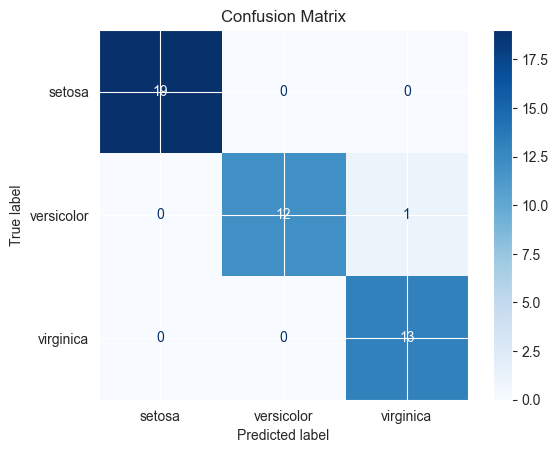

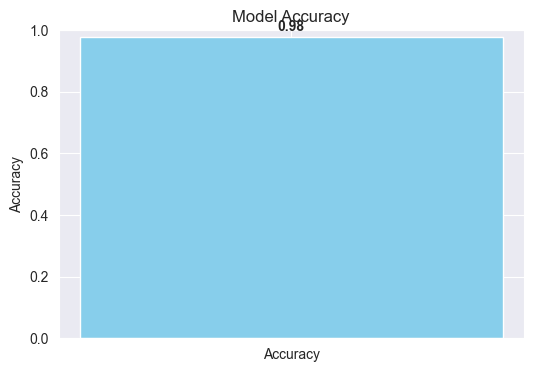

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB

sklearn_model = GaussianNB()
sklearn_model.fit(X_train, y_train)
sklearn_predictions = sklearn_model.predict(X_test)

sklearn_accuracy = sum(1 for i in range(len(y_test)) if y_test.values[i] == sklearn_predictions[i]) / len(y_test)
print(f'Scikit-learn Accuracy: {sklearn_accuracy * 100:.2f}%')

cm = confusion_matrix(y_test, sklearn_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sklearn_model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

metrics = ['Accuracy']
values = [sklearn_accuracy]

plt.figure(figsize=(6, 4))
plt.bar(metrics, values, color='skyblue')
plt.ylim(0, 1)
plt.title('Model Accuracy')
plt.ylabel('Accuracy')

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

NaiveBayes Accuracy: 97.78%
NaiveBayes Fit Time: 0.0000 seconds
NaiveBayes Predict Time: 0.0051 seconds
NaiveBayes Total Time: 0.0051 seconds
Scikit-learn Accuracy: 97.78%
Scikit-learn Fit Time: 0.0021 seconds
Scikit-learn Predict Time: 0.0011 seconds
Scikit-learn Total Time: 0.0032 seconds


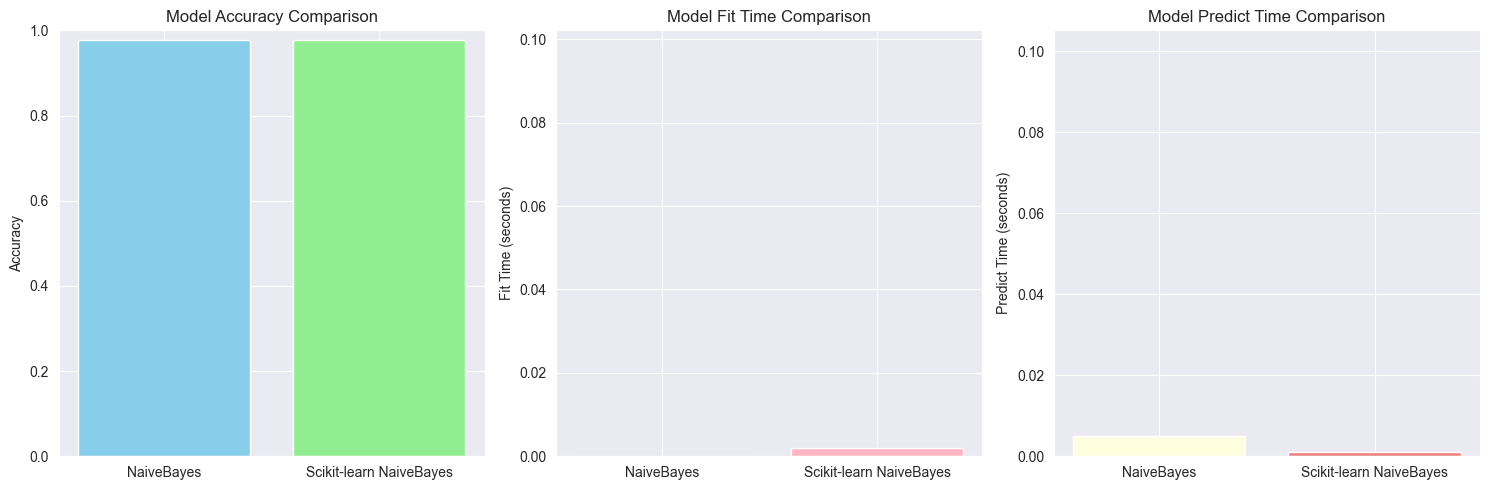

In [13]:
import time
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB

start_fit_naivebayes = time.time()
model = NaiveBayes()
model.fit(X_train.values, y_train.values)
fit_naivebayes_time = time.time() - start_fit_naivebayes

start_predict_naivebayes = time.time()
predictions_naivebayes = model.predict(X_test.values)
predict_naivebayes_time = time.time() - start_predict_naivebayes

naivebayes_time = fit_naivebayes_time + predict_naivebayes_time  

accuracy_naivebayes = accuracy_score(y_test, predictions_naivebayes)
print(f'NaiveBayes Accuracy: {accuracy_naivebayes * 100:.2f}%')
print(f'NaiveBayes Fit Time: {fit_naivebayes_time:.4f} seconds')
print(f'NaiveBayes Predict Time: {predict_naivebayes_time:.4f} seconds')
print(f'NaiveBayes Total Time: {naivebayes_time:.4f} seconds')

start_fit_sklearn = time.time()
sklearn_model = GaussianNB()
sklearn_model.fit(X_train, y_train)
fit_sklearn_time = time.time() - start_fit_sklearn

start_predict_sklearn = time.time()
sklearn_predictions = sklearn_model.predict(X_test)
predict_sklearn_time = time.time() - start_predict_sklearn

sklearn_time = fit_sklearn_time + predict_sklearn_time  

accuracy_sklearn = accuracy_score(y_test, sklearn_predictions)
print(f'Scikit-learn Accuracy: {accuracy_sklearn * 100:.2f}%')
print(f'Scikit-learn Fit Time: {fit_sklearn_time:.4f} seconds')
print(f'Scikit-learn Predict Time: {predict_sklearn_time:.4f} seconds')
print(f'Scikit-learn Total Time: {sklearn_time:.4f} seconds')

models = ['NaiveBayes', 'Scikit-learn NaiveBayes']
accuracies = [accuracy_naivebayes, accuracy_sklearn]
times = [naivebayes_time, sklearn_time]

fit_times = [fit_naivebayes_time, fit_sklearn_time]
predict_times = [predict_naivebayes_time, predict_sklearn_time]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

plt.subplot(1, 3, 2)
plt.bar(models, fit_times, color=['lightblue', 'lightpink'])
plt.ylim(0, max(fit_times) + 0.1)
plt.title('Model Fit Time Comparison')
plt.ylabel('Fit Time (seconds)')

plt.subplot(1, 3, 3)
plt.bar(models, predict_times, color=['lightyellow', 'lightcoral'])
plt.ylim(0, max(predict_times) + 0.1)
plt.title('Model Predict Time Comparison')
plt.ylabel('Predict Time (seconds)')

plt.tight_layout()
plt.show()


NaiveBayes Accuracy: 97.78%
NaiveBayes F1-Score: 0.98
NaiveBayes Precision: 0.98
NaiveBayes Recall: 0.98

Classification Report for Naive Bayes (Custom Implementation):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45

Scikit-learn Accuracy: 97.78%
Scikit-learn F1-Score: 0.98
Scikit-learn Precision: 0.98
Scikit-learn Recall: 0.98

Classification Report for Scikit-learn Naive Bayes:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg

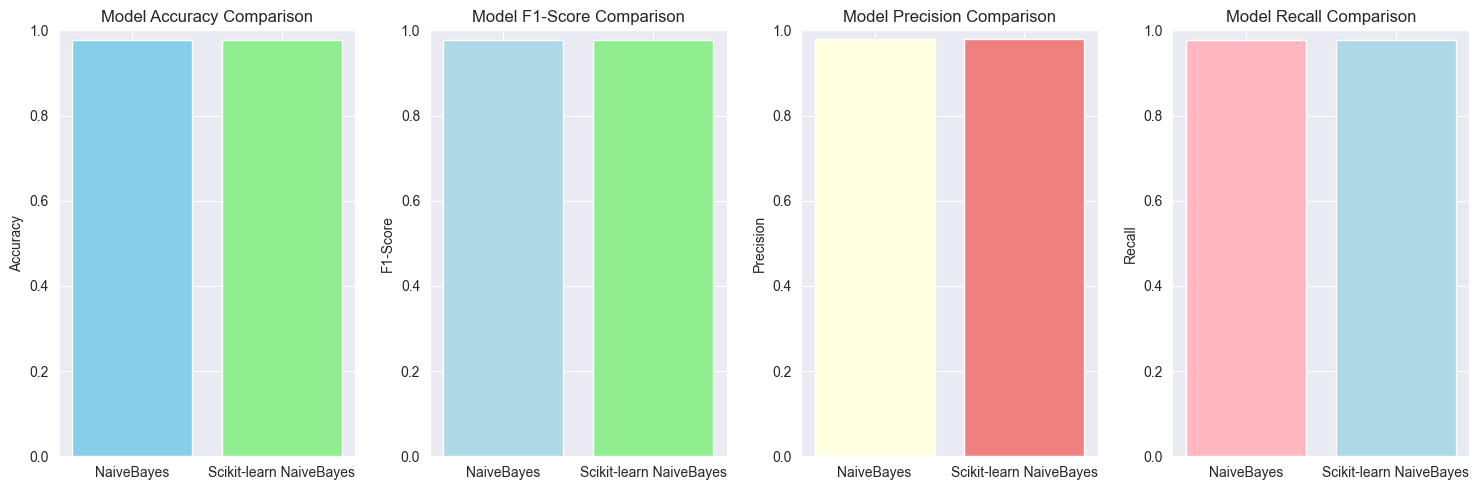

In [14]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
import time
import matplotlib.pyplot as plt
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

accuracy_naivebayes = accuracy_score(y_test, predictions_naivebayes)
f1_naivebayes = f1_score(y_test, predictions_naivebayes, average='weighted')
precision_naivebayes = precision_score(y_test, predictions_naivebayes, average='weighted')
recall_naivebayes = recall_score(y_test, predictions_naivebayes, average='weighted')

print(f'NaiveBayes Accuracy: {accuracy_naivebayes * 100:.2f}%')
print(f'NaiveBayes F1-Score: {f1_naivebayes:.2f}')
print(f'NaiveBayes Precision: {precision_naivebayes:.2f}')
print(f'NaiveBayes Recall: {recall_naivebayes:.2f}')
print('\nClassification Report for Naive Bayes (Custom Implementation):')
print(classification_report(y_test, predictions_naivebayes))

accuracy_sklearn = accuracy_score(y_test, sklearn_predictions)
f1_sklearn = f1_score(y_test, sklearn_predictions, average='weighted')
precision_sklearn = precision_score(y_test, sklearn_predictions, average='weighted')
recall_sklearn = recall_score(y_test, sklearn_predictions, average='weighted')

print(f'Scikit-learn Accuracy: {accuracy_sklearn * 100:.2f}%')
print(f'Scikit-learn F1-Score: {f1_sklearn:.2f}')
print(f'Scikit-learn Precision: {precision_sklearn:.2f}')
print(f'Scikit-learn Recall: {recall_sklearn:.2f}')
print('\nClassification Report for Scikit-learn Naive Bayes:')
print(classification_report(y_test, sklearn_predictions))

models = ['NaiveBayes', 'Scikit-learn NaiveBayes']
accuracies = [accuracy_naivebayes, accuracy_sklearn]
f1_scores = [f1_naivebayes, f1_sklearn]
precisions = [precision_naivebayes, precision_sklearn]
recalls = [recall_naivebayes, recall_sklearn]

plt.figure(figsize=(15, 5))

# Porovnanie accuracy
plt.subplot(1, 4, 1)
plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

# Porovnanie F1-Score
plt.subplot(1, 4, 2)
plt.bar(models, f1_scores, color=['lightblue', 'lightgreen'])
plt.ylim(0, 1)
plt.title('Model F1-Score Comparison')
plt.ylabel('F1-Score')

# Porovnanie Precision
plt.subplot(1, 4, 3)
plt.bar(models, precisions, color=['lightyellow', 'lightcoral'])
plt.ylim(0, 1)
plt.title('Model Precision Comparison')
plt.ylabel('Precision')

# Porovnanie Recall
plt.subplot(1, 4, 4)
plt.bar(models, recalls, color=['lightpink', 'lightblue'])
plt.ylim(0, 1)
plt.title('Model Recall Comparison')
plt.ylabel('Recall')

plt.tight_layout()
plt.show()

